In [1]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df = df.loc[:, ~df.columns.str.contains('Raw')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df = df.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T

Como hay tantas variables, procedemos a descartar aquellas que sean redundantes

### Lecturas bajas

Consideramos variables con lectuas bajas aquellas que tengan una frecuencia mayor del 50% con lecturas de menor de un threshold:

In [10]:
for thres in [0.1,0.2,0.3,0.5,0.6,0.7,0.8,0.9]:
    estadisticas = pd.DataFrame({
    'NoCeros': (df != 0).sum(),
    'CercanoCero': (df < thres).sum(),
    'Porcentaje de lencturas cercanas a cero' : (df < thres).sum()/35,
    'Media': df.mean(),
    'Desviación': df.std(),
    'Suma total': df.sum(),
    'Maximo' : df.max(),
    'Minimo' : df.min()
    })

    print(f'Lecturas menores de {thres} con una frecuencia de más del 50% hay', len(estadisticas[estadisticas['Porcentaje de lencturas cercanas a cero'] > 0.5]),'variables')

Lecturas menores de 0.1 con una frecuencia de más del 50% hay 0 variables
Lecturas menores de 0.2 con una frecuencia de más del 50% hay 1 variables
Lecturas menores de 0.3 con una frecuencia de más del 50% hay 3 variables
Lecturas menores de 0.5 con una frecuencia de más del 50% hay 10 variables
Lecturas menores de 0.6 con una frecuencia de más del 50% hay 16 variables
Lecturas menores de 0.7 con una frecuencia de más del 50% hay 37 variables
Lecturas menores de 0.8 con una frecuencia de más del 50% hay 67 variables
Lecturas menores de 0.9 con una frecuencia de más del 50% hay 95 variables


Se elige 0.6

In [11]:
thres_elegido = 0.6

estadisticas = pd.DataFrame({
    'NoCeros': (df != 0).sum(),
    'CercanoCero': (df < 0.5).sum(),
    'Porcentaje de lencturas cercanas a cero' : (df < thres_elegido).sum()/35,
    'Media': df.mean(),
    'Desviación': df.std(),
    'Suma total': df.sum(),
    'Maximo' : df.max(),
    'Minimo' : df.min()
    }).sort_values('Porcentaje de lencturas cercanas a cero', ascending = False)
vars_est = estadisticas[estadisticas['Porcentaje de lencturas cercanas a cero'] > 0.5]
vars_est

,NoCeros,CercanoCero,Porcentaje de lencturas cercanas a cero,Media,Desviación,Suma total,Maximo,Minimo
hgnc_symbol,,,,,,,,
DNAAF4-CCPG1,35,27,0.800000,0.407633,0.687793,14.267146,2.909775,0.011532
LYPLAL1-AS1,35,23,0.714286,0.530408,0.425495,18.564288,1.953195,0.014390
LINC00865,35,25,0.714286,0.665514,0.785052,23.292979,3.530602,0.052633
LINC02388,35,21,0.685714,0.840344,1.071354,29.412056,3.792128,0.015304
LINC01697,35,22,0.685714,0.716995,0.951829,25.094813,3.921769,0.018421
LINC02506,35,21,0.657143,0.974187,1.751366,34.096542,7.400966,0.011532
LINC02160,35,21,0.657143,0.621431,0.468060,21.750100,1.830866,0.046138
LINC02427,35,17,0.600000,0.572845,0.359135,20.049577,1.340731,0.056041
LINC02804,35,21,0.600000,0.536994,0.479179,18.794805,1.704988,0.043169


In [12]:
vars_excluir = vars_est.reset_index()['hgnc_symbol'].to_list()
df1 = df.drop(columns=vars_excluir)

print(len(df.columns),'variables →',len(df1.columns),'variables')

695 variables → 679 variables


### Correlaciones

La correlación de Spearman no elimina ninguna variable ya que de acuerdo con ella, no hay ninguna correlación a un threshold > 0.95

In [15]:
df_list = []
threshold = 0.8
correlaciones_vars = df1.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df1.columns)        
df1 = df1.drop(columns=columns_to_drop)   
print(nvarsAntes,'variables →',len(df1.columns),'variables')

679 variables → 662 variables


### Tests

Se procede a hacer un test para cada variable para determinar si existen diferencias significativas entre el grupo de Tratamiento y Control. Esto nos permitirá saber si cada variable es estadíticamente diferente o no. Las que no son diferentes podemos procederlas a eliminarlas ya que el objetivo de este análisis es determinar las diferencias entre ambos grupos

In [16]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [17]:
####Dividmos el data set en dos: Uno de tratamiento y otro de control

df1_ct = df1.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

In [18]:
variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

In [19]:
print(len(variables),'→',len(variablesIncluir))

662 → 75


In [20]:
df1 = df1[variablesIncluir]

### Clustering


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [13]:
scaler = StandardScaler()
df_scaled  = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled = df_scaled.set_index(df1.index)

C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

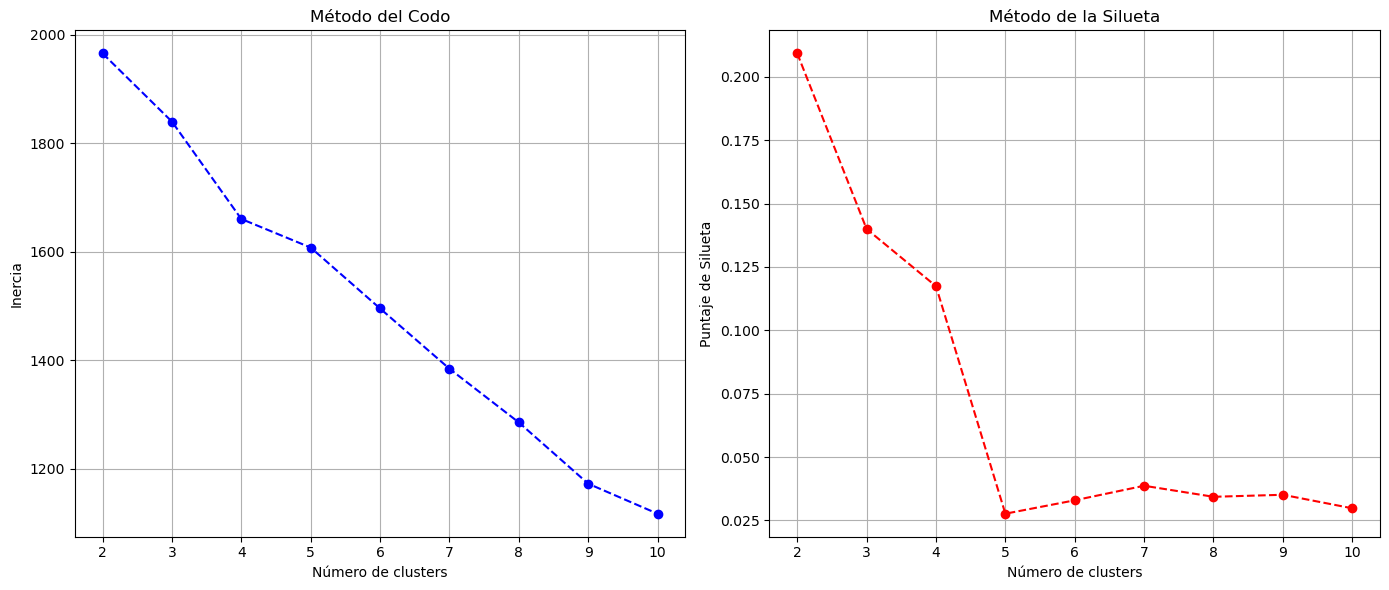

In [14]:
# Método del Codo
df_scaled1 = df_scaled.copy()
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Evaluamos entre 2 y 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_scaled1)
    
    # Guardamos la inercia para la técnica del codo
    inertia.append(kmeans.inertia_)
    
    # Calculamos el score de silueta para el método de silueta
    score = silhouette_score(df_scaled1, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfico del Método del Codo
plt.figure(figsize=(14, 6))

# Subgráfico para la técnica del codo
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True)

# Subgráfico para el Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
df_scaled1 = df_scaled.copy()
ncluster = 2
kmeans = KMeans(n_clusters=ncluster, random_state=42) #2 clusters, uno de control y otro de tratamiento
kmeans.fit(df_scaled1)
# Asignar cada variable a un cluster
clusters = kmeans.labels_
df_scaled1['cluster'] = clusters

for cluster in range(ncluster):
    df_scaled1Clust = df_scaled1[df_scaled1['cluster'] == cluster].reset_index()
    df_scaled1Clust['Grupo'] = np.where(df_scaled1Clust['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled1Clust['index'].str.contains('C'), 'Control', 'Otro'))
    conteo = df_scaled1Clust['Grupo'].value_counts()
    proporcion = df_scaled1Clust['Grupo'].value_counts(normalize=True) * 100
    print('CLUSTER',cluster)
    for categoria, (cantidad, prop) in zip(conteo.index, zip(conteo, proporcion)):
            print(f"{categoria}: {cantidad} ({prop:.2f}%)")

CLUSTER 0
Tratamiento: 22 (100.00%)
CLUSTER 1
Control: 11 (84.62%)
Tratamiento: 2 (15.38%)


C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Este clustering nos justifica que hay diferencia estadísticas entre el grupo de control y tratamiento pero hay que determinar cuáles son

### Árbol de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [24]:
scaler = StandardScaler()
df_scaled  = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled = df_scaled.set_index(df1.index)

In [26]:
df_scaled2 = df_scaled.copy()
df_scaled2 = df_scaled2.reset_index()
df_scaled2['Grupo'] = np.where(df_scaled2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled2['index'].str.contains('C'), 'Control', 'Otro'))
df_scaled2 = df_scaled2.set_index('index')
df_scaled2 = pd.get_dummies(df_scaled2, columns=['Grupo'], drop_first=True)
df_scaled2['Grupo_Tratamiento'] = df_scaled2['Grupo_Tratamiento'].astype(int)

#### Estimación única

In [29]:
X = df_scaled2.drop(columns=["Grupo_Tratamiento"])  
y = df_scaled2["Grupo_Tratamiento"]  

# Crear el modelo de árbol de decisión
dt = DecisionTreeClassifier(
    criterion='gini',         # Medir la calidad de la división
    max_depth=5,              # Limitar la profundidad del árbol
    min_samples_split=20,     # Al menos 10 muestras para dividir un nodo
    min_samples_leaf=5,       # Al menos 5 muestras en cada hoja
    random_state=42           # Para reproducibilidad
)

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calcular accuracy de entrenamiento y test usando validación cruzada
train_accuracies = []
test_accuracies = []

for train_index, test_index in cv.split(X, y):
    # Dividir en entrenamiento y test según los índices
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Entrenar el modelo en el conjunto de entrenamiento
    dt.fit(X_train, y_train)
    
    # Predecir en entrenamiento y test
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    
    # Calcular el accuracy en entrenamiento y test
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Resultados
mean_train_accuracy = np.mean(train_accuracies)
mean_test_accuracy = np.mean(test_accuracies)
std_train_accuracy = np.std(train_accuracies)
std_test_accuracy = np.std(test_accuracies)

print(f"Accuracy medio en entrenamiento (cross-validation): {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}")
print(f"Accuracy medio en test (cross-validation): {mean_test_accuracy:.4f} ± {std_test_accuracy:.4f}")

# Importancia de variables
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 variables más importantes:")
print(importances.head(10))


Accuracy medio en entrenamiento (cross-validation): 0.9500 ± 0.0175
Accuracy medio en test (cross-validation): 0.8000 ± 0.0700

Top 10 variables más importantes:
ARRDC3-AS1       0.968992
LINC00893        0.031008
ALDH1L1-AS2      0.000000
BACE1-AS         0.000000
BAIAP2-DT        0.000000
C10orf25         0.000000
C8orf49          0.000000
CBR3-AS1         0.000000
CCDC144NL-AS1    0.000000
CCND2-AS1        0.000000
dtype: float64


Según este árbol de decisión las variables más importantes para categorizar si una persona era del grupo de tratamiento o de control son:

ARRDC3-AS1

LINC01844

#### Monte Carlo

In [26]:
X = df_scaled2.drop(columns=["cluster", "Grupo_Tratamiento"])  
y = df_scaled2["Grupo_Tratamiento"]
n_iteraciones = 5000
max_depth_options = list(range(3, 10))
min_samples_split_options = list(range(2, 30))
min_samples_leaf_options = list(range(1, 15))
split_options = [0.1,0.15,0.2,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.3]
criterions = ['gini', 'entropy']
resultados = []

for i in range(n_iteraciones):
    split_size = random.choice(split_options)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=split_size)
    max_depth = random.choice(max_depth_options)
    min_samples_split = random.choice(min_samples_split_options)
    min_samples_leaf = random.choice(min_samples_leaf_options)
    criterion = random.choice(criterions)
    dt = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random.choice(list(range(1,100000000)))
    )
    dt.fit(X_train, y_train)
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    important_features = []
    for idx, f in enumerate(X.columns):
        importance = dt.feature_importances_[idx]
        if importance > 0:
            important_features.append((f, importance))
    if important_features:
        for feature, importance in important_features:
            resultados.append({
                'Iteration': i,
                'Feature': feature,
                'Importance': importance,
                'Train Accuracy': train_accuracy,
                'Test Accuracy': test_accuracy
            })

# Crear un DataFrame con los resultados
df_results = pd.DataFrame(resultados)

Error in callback <function _draw_all_if_interactive at 0x0000021A0FD77E20> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [32]:
df_results = pd.DataFrame(resultados)
df_results.to_csv('../WorkingFiles/LncRNA_MonteCarlo_arbolDec.csv',index = False)

In [55]:
df_results

,Iteration,Feature,Importance,Train Accuracy,Test Accuracy
0,0,LINC00964,0.165578,0.931034,0.666667
1,0,LINC02208,0.834422,0.931034,0.666667
2,1,LINC01844,1.000000,0.958333,0.818182
3,2,LINC01844,1.000000,0.961538,0.777778
4,3,LINC01569,1.000000,0.892857,0.714286
...,...,...,...,...,...
2498,2494,LINC02208,1.000000,0.962963,0.625000
2499,2495,LINC02208,1.000000,0.961538,0.666667
2500,2496,LINC02208,1.000000,0.857143,1.000000
2501,2498,LINC01569,1.000000,0.960000,0.700000


In [58]:
mostImpFeaturesTree =  df_results.groupby('Feature').agg(
    Frecuencia=('Feature', 'count'),
    Promedio_Importancia=('Importance', 'mean'),
    Promedio_Train_accuracy=('Train Accuracy','mean'),
    Promedio_Test_accuracy=('Test Accuracy','mean')
).reset_index().sort_values(by='Frecuencia', ascending=False)
print('Las características que más se repiten son:')
mostImpFeaturesTree.head(10)

Las características que más se repiten son:


,Feature,Frecuencia,Promedio_Importancia,Promedio_Train_accuracy,Promedio_Test_accuracy
44,LINC01844,561,0.972152,0.939319,0.809469
1,ARRDC3-AS1,286,0.925601,0.962658,0.812551
47,LINC02208,281,0.952903,0.931234,0.736773
12,DIO3OS,219,0.929565,0.951215,0.712602
43,LINC01569,127,0.932669,0.934969,0.698467
35,LINC00964,72,0.875563,0.957922,0.680387
69,SNHG19,72,0.881224,0.956086,0.667171
39,LINC01278,68,0.872686,0.939497,0.646396
60,OSER1-DT,60,0.952587,0.920285,0.709488
48,LINC02254,56,0.907019,0.923698,0.614293


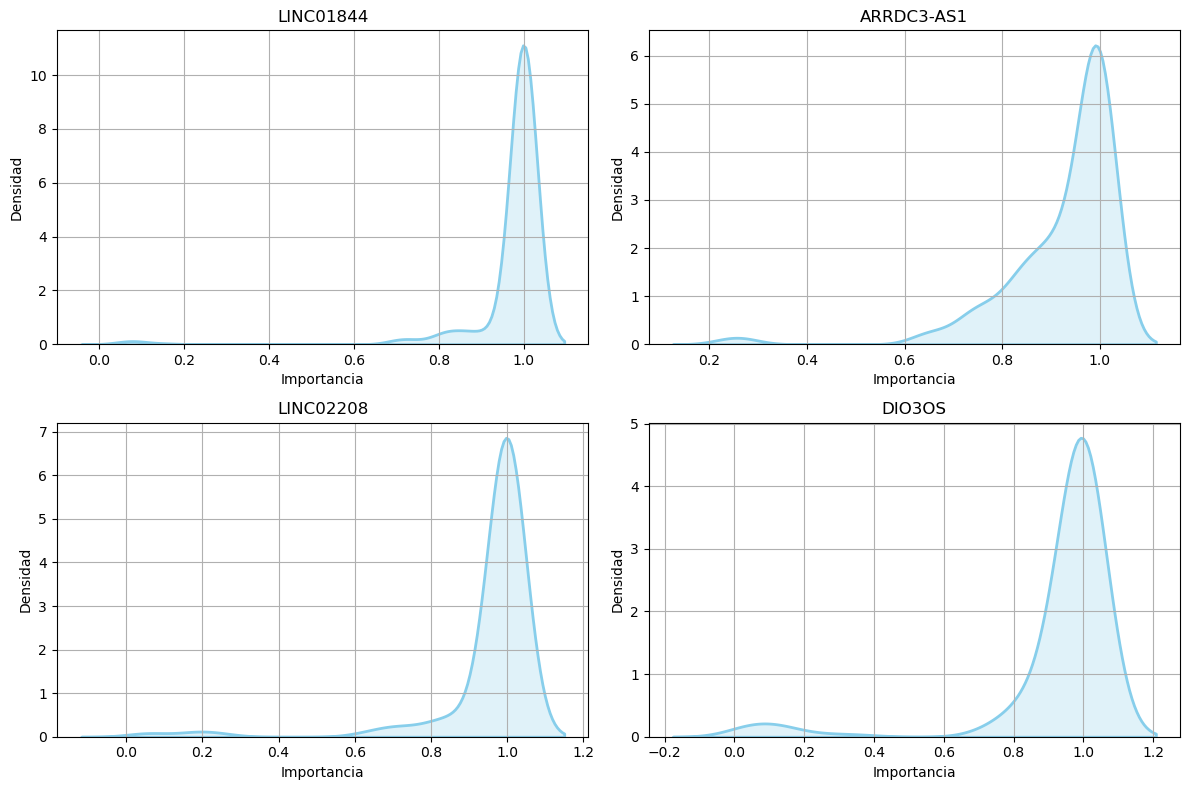

In [54]:
df_results = pd.read_csv('../WorkingFiles/LncRNA_MonteCarlo_arbolDec.csv')
features = ['LINC01844', 'ARRDC3-AS1', 'LINC02208', 'DIO3OS']

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

axes = axes.flatten()
for i, feature in enumerate(features):
    subset = df_results[df_results['Feature'] == feature]
    sns.kdeplot(
        subset['Importance'], 
        fill=True, 
        color="skyblue", 
        linewidth=2, 
        ax=axes[i]
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('Importancia')
    axes[i].set_ylabel('Densidad')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Regresión 

In [59]:
import statsmodels.api as sm

### Lineal

In [ ]:
X = df_scaled2.drop(columns=["Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 5 variables aleatorias y hacer la regresión
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 5 variables
    selected_features = random.sample(list(X.columns), 5)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    # Ajustar el modelo de regresión lineal
    model = sm.OLS(y, X_selected_with_intercept)
    result = model.fit()
    
    for feature in selected_features:
        coefficients_dict[feature].append((float(result.params[feature])))
        p_values_dict[feature].append((float(result.pvalues[feature])))
        


mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

results_df = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

results_df = results_df[results_df['P-Valor Promedio']<0.05]



In [90]:
mostImpFeaturesRegression = results_df.sort_values('Coeficiente Promedio', ascending = False)
mostImpFeaturesRegression

,Variable,Coeficiente Promedio,P-Valor Promedio
1,ARRDC3-AS1,0.205956,0.010377
41,LINC01547,0.176826,0.036054
24,H19,0.145953,0.049303
75,TRAF3IP2-AS1,-0.139338,0.047936
68,SLC25A5-AS1,-0.145096,0.046319
12,DIO3OS,-0.184494,0.036071
44,LINC01844,-0.193679,0.036000
69,SNHG19,-0.202750,0.011485
47,LINC02208,-0.231946,0.002836
35,LINC00964,-0.235984,0.006486


#### Logistica

In [60]:
import warnings
warnings.filterwarnings("ignore")

In [94]:
X = df_scaled2.drop(columns=["cluster", "Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 3 variables aleatorias y hacer la regresión logística
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 3 variables
    selected_features = random.sample(list(X.columns), 1)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    try:
        model = sm.Logit(y, X_selected_with_intercept)
        result = model.fit(disp=0)  # Evita que se muestre el resultado durante el ajuste
        
        for feature in selected_features:
            coefficients_dict[feature].append(float(result.params[feature]))
            p_values_dict[feature].append(float(result.pvalues[feature]))
    except:
        # Si ocurre un error (como singularidad), simplemente continuar con la siguiente iteración
        continue
# Calcular las medias de los coeficientes y p-valores
mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

# Crear DataFrame con los resultados
results_df_log = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

# Filtrar para obtener solo aquellas variables con p-valor menor que 0.05
#results_df = results_df[results_df['P-Valor Promedio'] < 0.05]

In [100]:
results_df_log_MasSignificativos = results_df_log[results_df_log['P-Valor Promedio'] < 0.05].sort_values('Coeficiente Promedio',ascending = False)
#results_df_log_MasSignificativos['CoeficienteInterpretacion'] = np.exp(results_df_log_MasSignificativos['Coeficiente Promedio'])
results_df_log_MasSignificativos = results_df_log_MasSignificativos
results_df_log_MasSignificativos

,Variable,Coeficiente Promedio,P-Valor Promedio
73,TGFB2-OT1,5.944962,0.015438
1,ARRDC3-AS1,5.775529,0.021997
48,LINC02254,4.136584,0.010154
39,LINC01278,3.630203,0.006068
8,CCDC144NL-AS1,3.117003,0.012793
...,...,...,...
37,LINC01151,-2.136273,0.001689
12,DIO3OS,-2.442365,0.006844
35,LINC00964,-2.921044,0.003501
47,LINC02208,-4.169971,0.008562


#### Conjunto variables

In [119]:
treelist = mostImpFeaturesTree['Feature'].to_list()
reglist = mostImpFeaturesRegression['Variable'].to_list()
loglists = results_df_log_MasSignificativos['Variable'].to_list()

all_items = set(treelist + reglist + loglists)
df_comparacion = pd.DataFrame({'variable': list(all_items)})
df_comparacion['Arbol'] = df_comparacion['variable'].isin(treelist).astype(int)
df_comparacion['OLS'] = df_comparacion['variable'].isin(reglist).astype(int)
df_comparacion['Logistic'] = df_comparacion['variable'].isin(loglists).astype(int)

df_comparacion['frecuencia_total'] = (
    df_comparacion['Arbol'] +
    df_comparacion['OLS'] +
    df_comparacion['Logistic']
)
df_comparacion = df_comparacion.sort_values(by='frecuencia_total', ascending=False)
df_comparacion[df_comparacion['frecuencia_total'] >= 2]

,variable,Arbol,OLS,Logistic,frecuencia_total
3,DIO3OS,1,1,1,3
55,LINC02208,1,1,1,3
39,ARRDC3-AS1,1,1,1,3
43,LINC01844,1,1,1,3
44,SNHG19,1,1,1,3
51,LINC00964,1,1,1,3
15,LINC01547,0,1,1,2
48,LINC02254,1,0,1,2
34,SLC25A5-AS1,0,1,1,2
64,LINC01569,1,0,1,2


## Creación de data frames

### Clustering de variables

Vamos a trasponer el data set al tener más variables que observaciones y le hacemos un clustering. Al hacer esto, el algoritmo nos dirá qué conjuntos de variables son más semejantes entre sí para agruparlas. El resultado sería que se agrupan las variables en diferentes clusters, haciendo así diferentes Data sets con variables similares. 

In [120]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

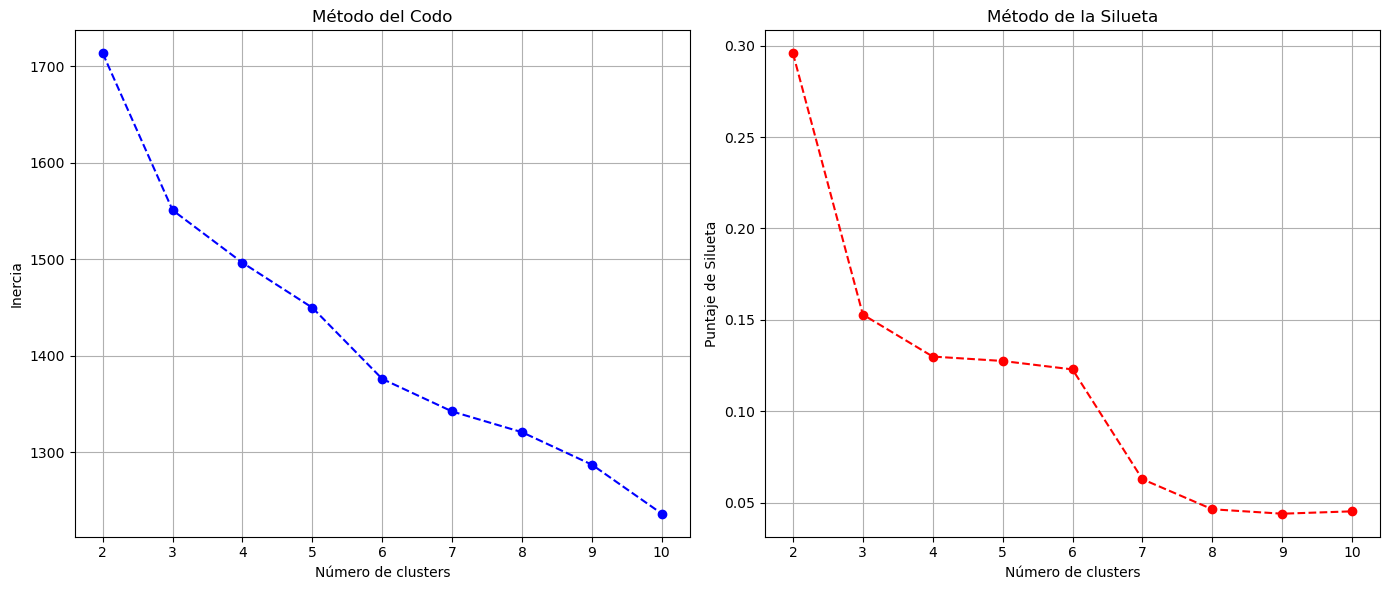

In [121]:
scaler = StandardScaler()
df_scaled  = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled = df_scaled.set_index(df1.index)

df_transposed = df_scaled.T 

# Método del Codo
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Evaluamos entre 2 y 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_transposed)
    
    # Guardamos la inercia para la técnica del codo
    inertia.append(kmeans.inertia_)
    
    # Calculamos el score de silueta para el método de silueta
    score = silhouette_score(df_transposed, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfico del Método del Codo
plt.figure(figsize=(14, 6))

# Subgráfico para la técnica del codo
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True)

# Subgráfico para el Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

In [122]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(df_transposed)

# Asignar cada variable a un cluster
clusters = kmeans.labels_
df_transposed['cluster'] = clusters

lista_df_clustersVars = {}
for cluster in range(n_clusters):
    df_cluster = df_transposed[df_transposed['cluster'] == cluster]
    print('DataFrame', cluster,':',len(df_cluster), 'variables')
    lista_df_clustersVars.update({cluster : df_cluster.drop('cluster', axis = 1).T})

DataFrame 0 : 24 variables
DataFrame 1 : 20 variables
DataFrame 2 : 33 variables


C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [123]:
lista_df_clustersVars[0].to_csv('../WorkingFiles/LncRNA_df1.csv')
lista_df_clustersVars[1].to_csv('../WorkingFiles/LncRNA_df2.csv')
lista_df_clustersVars[2].to_csv('../WorkingFiles/LncRNA_df3.csv')

### Trabajo con cada dataframe

#### Árboles de decisión

In [231]:
vars_imp_df = {}
for i in range(len(lista_df_clustersVars)):
    print(f'DATA FRAME {i}')
    df_sub = lista_df_clustersVars[i].copy()
    
    df_sub = df_sub.drop('clusterObs', axis = 1)
    df_sub = df_sub.reset_index()
    df_sub['Grupo'] = np.where(df_sub['index'].str.contains('A'), 'Tratamiento', 
                  np.where(df_sub['index'].str.contains('C'), 'Control', 'Otro'))
    df_sub = df_sub.set_index('index')
    df_sub = pd.get_dummies(df_sub, columns=['Grupo'], drop_first=True)
    df_sub['Grupo_Tratamiento'] = df_sub['Grupo_Tratamiento'].astype(int)
    # Definir variables independientes y objetivo
    X = df_sub.drop(columns=["Grupo_Tratamiento"])  
    y = df_sub["Grupo_Tratamiento"]  
    
    # Crear el modelo
    dt = DecisionTreeClassifier(
        criterion='gini',
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=10,
        max_features=1,
        random_state=42
    )
    
    # Configurar validación cruzada estratificada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calcular accuracy de entrenamiento y test usando validación cruzada
    train_accuracies = []
    test_accuracies = []
    
    for train_index, test_index in cv.split(X, y):
        # Dividir en entrenamiento y test según los índices
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Entrenar el modelo en el conjunto de entrenamiento
        dt.fit(X_train, y_train)
        
        # Predecir en entrenamiento y test
        y_train_pred = dt.predict(X_train)
        y_test_pred = dt.predict(X_test)
        
        # Calcular el accuracy en entrenamiento y test
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
    
    # Resultados
    mean_train_accuracy = np.mean(train_accuracies)
    mean_test_accuracy = np.mean(test_accuracies)
    std_train_accuracy = np.std(train_accuracies)
    std_test_accuracy = np.std(test_accuracies)
    
    print(f"Accuracy medio en entrenamiento (cross-validation): {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}")
    print(f"Accuracy medio en test (cross-validation): {mean_test_accuracy:.4f} ± {std_test_accuracy:.4f}")
    
    # Importancia de variables
    importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\nTop 3 variables más importantes:")
    print(importances.head(3))
    
    imp_df = pd.DataFrame(importances).reset_index()
    variables_imp = imp_df[imp_df[0] != 0]['index'].to_list()
    vars_imp_df.update({i : variables_imp})
    
    # Visualizar el árbol
    #plot_tree(dt, filled=True, feature_names=X.columns, class_names=["Control", "Tratamiento"], rounded=True)
    #plt.show()
vars_imp_df

DATA FRAME 0
Accuracy medio en entrenamiento (cross-validation): 0.7929 ± 0.0350
Accuracy medio en test (cross-validation): 0.7429 ± 0.1666

Top 3 variables más importantes:
LINP1         1.0
ARRDC3-AS1    0.0
BAIAP2-DT     0.0
dtype: float64
DATA FRAME 1
Accuracy medio en entrenamiento (cross-validation): 0.7500 ± 0.0391
Accuracy medio en test (cross-validation): 0.7143 ± 0.1565

Top 3 variables más importantes:
LINC01550    1.0
DIO3OS       0.0
EIF3J-DT     0.0
dtype: float64
DATA FRAME 2
Accuracy medio en entrenamiento (cross-validation): 0.8214 ± 0.0319
Accuracy medio en test (cross-validation): 0.7714 ± 0.1457

Top 3 variables más importantes:
TGFB2-OT1      1.0
ALDH1L1-AS2    0.0
BACE1-AS       0.0
dtype: float64


{0: ['LINP1'], 1: ['LINC01550'], 2: ['TGFB2-OT1']}

El arbol de decisión genérico marcaba que las variables importantes para categorizar si un individuo es de control o tratamiento eran:
ARRDC3-AS1
LINC01844

Los arboles para cada sub data set marcan: 
0: ['LINP1'], 
1: ['LINC01550'], 
2: ['TGFB2-OT1']

Para cada data frame creado en el clustering anterior, se elabora un clustering de dos grupos (tratamiento y control) para ver si el algoritmo reparte en cada data frame a los pacientes de control en un cluster y los de tratamiento en otro. Para ello, primero vemos a hacer un clustering de 2 grupos para todo el data set para ver si de manera genérica el algoritmo incluye los individuos de tratamiento en un cluster y los individuos de control en otro.

Vemos las proporciones de tratamiento y control de cada cluster para compararlas con la proporciones para cada data frame genearado en apartado anterior y así, ver si estas proporciones se mantienen en cada dúo de clusters de cada data frame 

In [127]:
dobleClust = {}
for i in lista_df_clustersVars:
    
    df_clustVars = lista_df_clustersVars[i]
    kmeans = KMeans(n_clusters=2, random_state=42) #2 clusters, uno de control y otro de tratamiento
    kmeans.fit(df_clustVars)

    clusters = kmeans.labels_
    df_clustVars['clusterObs'] = clusters
    
    lista_df_clusterObs = {}
    print(f"DATAFRAME {i}")
    for cluster in range(2):
        df_clustObs = df_clustVars[df_clustVars['clusterObs'] == cluster]
        df_clustObs = df_clustObs.reset_index()
        df_clustObs['Grupo'] = np.where(df_clustObs['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_clustObs['index'].str.contains('C'), 'Control', 'Otro'))
        conteo = df_clustObs['Grupo'].value_counts()
        proporcion = df_clustObs['Grupo'].value_counts(normalize=True) * 100
        
        print(f"CLUSTER {cluster}")
        for categoria, (cantidad, prop) in zip(conteo.index, zip(conteo, proporcion)):
            print(f"{categoria}: {cantidad} ({prop:.2f}%)")
        lista_df_clusterObs.update({cluster : df_clustObs})
    dobleClust.update({i : lista_df_clusterObs})

DATAFRAME 0
CLUSTER 0
Tratamiento: 20 (100.00%)
CLUSTER 1
Control: 11 (73.33%)
Tratamiento: 4 (26.67%)
DATAFRAME 1
CLUSTER 0
Tratamiento: 22 (95.65%)
Control: 1 (4.35%)
CLUSTER 1
Control: 10 (83.33%)
Tratamiento: 2 (16.67%)
DATAFRAME 2
CLUSTER 0
Tratamiento: 11 (50.00%)
Control: 11 (50.00%)
CLUSTER 1
Tratamiento: 13 (100.00%)


C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nacho\mambaforge\envs\innval\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Si bien las proporciones denotan alguna 